# 18 · Calibration Workflows

Finstack ships a calibration helper that ingests market quotes, solves curves, and returns enriched `MarketContext` objects. This notebook wires the test quote set into `SimpleCalibration`.

### Learning Objectives
- Load reusable quote sets (rates, forwards, credit, vols)
- Configure `SimpleCalibration` with solver options
- Inspect calibration reports and derived market data

In [ ]:
from datetime import date

from finstack.core.market_data.context import MarketContext
from finstack.valuations import calibration as cal

# Always define base_date - Bloomberg settle date
base_date = date(2025, 12, 10)


## 1. Discount Curve Calibration
We start by calibrating a USD-OIS discount curve directly with `DiscountCurveCalibrator`. The helper returns market quotes, so we recreate the short deposit and swap points inline before bootstrapping.

In [ ]:
# Bloomberg USD OIS curve data (Settle: 12/10/2025)
# Short-end deposits (< 1Y) and OIS swaps (>= 1Y)

# We use the conventions-first quote constructors so the quote *shape* matches the Rust library:
# day-count, payment/reset frequencies, and index live inside `InstrumentConventions`.

deposit_conv = cal.InstrumentConventions(
    day_count="ACT/360",
    settlement_days=2,
    calendar_id="usny",
    )
ois_fixed_leg = cal.InstrumentConventions(
    payment_frequency="1Y",
    settlement_days=2,
    payment_delay_days=2,
    calendar_id="usny",
    day_count="ACT/360"
    )
# NOTE: Bloomberg curve is **Fed Funds OIS**. Two important pieces:
# - The floating index should be a Fed Funds OIS-style identifier so the library selects the
#   correct overnight-RFR conventions.
# - `reset_lag` should typically be 0 for overnight compounding; the observation convention
#   (lookback/shift) is handled by the index's OIS compounding preset.
ois_float_leg = cal.InstrumentConventions(
    payment_frequency="1Y", 
    day_count="ACT/360", 
    reset_lag=0, 
    calendar_id="usny",
    index="USD-FEDFUNDS-OIS")

discount_quotes = [
    # Short-term deposits - using actual maturity dates from Bloomberg
    # cal.RatesQuote.deposit(date(2025, 12, 12), 0.0389, conventions=deposit_conv),  # 1D
    cal.RatesQuote.deposit(date(2025, 12, 19), 0.0364447, conventions=deposit_conv),  # 1W
    cal.RatesQuote.deposit(date(2025, 12, 26), 0.0364455, conventions=deposit_conv),  # 2W
    cal.RatesQuote.deposit(date(2026, 1, 2), 0.0365300, conventions=deposit_conv),    # 3W
    cal.RatesQuote.deposit(date(2026, 1, 12), 0.0364950, conventions=deposit_conv),   # 1M
    cal.RatesQuote.deposit(date(2026, 2, 12), 0.0364050, conventions=deposit_conv),   # 2M
    cal.RatesQuote.deposit(date(2026, 3, 12), 0.0363477, conventions=deposit_conv),   # 3M
    cal.RatesQuote.deposit(date(2026, 4, 13), 0.0361400, conventions=deposit_conv),   # 4M
    cal.RatesQuote.deposit(date(2026, 5, 12), 0.0359544, conventions=deposit_conv),   # 5M
    cal.RatesQuote.deposit(date(2026, 6, 12), 0.0358000, conventions=deposit_conv),   # 6M
    cal.RatesQuote.deposit(date(2026, 7, 13), 0.0355310, conventions=deposit_conv),   # 7M
    cal.RatesQuote.deposit(date(2026, 8, 12), 0.0352500, conventions=deposit_conv),   # 8M
    cal.RatesQuote.deposit(date(2026, 9, 14), 0.0350225, conventions=deposit_conv),   # 9M
    cal.RatesQuote.deposit(date(2026, 10, 13), 0.0347742, conventions=deposit_conv),  # 10M
    cal.RatesQuote.deposit(date(2026, 11, 12), 0.0345356, conventions=deposit_conv),  # 11M
    # OIS Swaps (>= 1Y)
    cal.RatesQuote.swap(
        date(2026, 12, 14),  # 1Y
        0.0343446,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2027, 6, 14),  # 18M
        0.0332849,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2027, 12, 13),  # 2Y
        0.0329864,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    # Extended tenors from Bloomberg (actual market rates)
    cal.RatesQuote.swap(
        date(2028, 12, 12),  # 3Y
        0.0330190,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2029, 12, 12),  # 4Y
        0.0333823,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2030, 12, 12),  # 5Y
        0.0338799,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2031, 12, 12),  # 6Y
        0.0344608,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2032, 12, 13),  # 7Y
        0.0350619,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2033, 12, 12),  # 8Y
        0.0356592,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2034, 12, 12),  # 9Y
        0.0362453,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2035, 12, 12),  # 10Y
        0.0368206,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2037, 12, 14),  # 12Y
        0.0378975,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2040, 12, 12),  # 15Y
        0.0391717,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2045, 12, 12),  # 20Y
        0.0402348,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2050, 12, 12),  # 25Y
        0.0403809,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2055, 12, 13),  # 30Y
        0.0401000,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2065, 12, 14),  # 40Y
        0.0390413,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
    cal.RatesQuote.swap(
        date(2075, 12, 12),  # 50Y
        0.0378761,
        fixed_leg_conventions=ois_fixed_leg,
        float_leg_conventions=ois_float_leg,
        is_ois=True,
    ),
]

# --- Calibration method toggle ---
# Keep Bootstrap as default; optionally switch to GlobalSolve (global multi-instrument solve).
USE_GLOBAL_SOLVE = True
USE_ANALYTICAL_JACOBIAN = True  # Optional hint; global solve falls back to FD if unsupported.

market = MarketContext()

calibration_method = (
    cal.CalibrationMethod.from_name(
        "global_solve", use_analytical_jacobian=USE_ANALYTICAL_JACOBIAN
    )
    if USE_GLOBAL_SOLVE
    else cal.CalibrationMethod.BOOTSTRAP
)

# `execute_calibration_v2` expects JSON-serializable step definitions.
method_json = (
    {"GlobalSolve": {"use_analytical_jacobian": USE_ANALYTICAL_JACOBIAN}}
    if USE_GLOBAL_SOLVE
    else "Bootstrap"
)
print(method_json)

quote_sets = {"ois": [q.to_market_quote() for q in discount_quotes]}
steps = [
    {
        "id": "disc",
        "quote_set": "ois",
        "kind": "discount",
        "curve_id": "USD-OIS",
        "currency": "USD",
        "base_date": str(base_date),
        "method": method_json,
        "interpolation": "monotone_convex",
        "extrapolation": "flat_forward",
    }
]

settings = cal.CalibrationConfig(tolerance=1e-8)

market, plan_report, step_reports = cal.execute_calibration_v2(
    "notebook_discount_curve",
    quote_sets,
    steps,
    settings=settings,
)

discount_curve = market.discount("USD-OIS")
discount_report = step_reports["disc"]
print("Discount curve calibrated:", discount_curve.id)
print("Calibration method:", calibration_method.name)
print("Plan success:", plan_report.success)
print("Step success:", discount_report.success)
print("Max residual:", discount_report.max_residual)
print("RMSE:", discount_report.rmse)
print("Number of knots:", len(discount_curve.points))

# Quick residual diagnostic: which instrument(s) are driving the fit error?
# (For the discount step, these are PV residuals per quote, normalized by notional.)
_top = sorted(discount_report.residuals.items(), key=lambda kv: abs(kv[1]), reverse=True)[:10]
print("\nTop residuals (abs):")
for k, v in _top:
    print(f"  {k}: {v:.3e}")

# Optional: quantify how different GlobalSolve is from Bootstrap
if USE_GLOBAL_SOLVE:
    steps_boot = [dict(steps[0], method="Bootstrap")]
    market_boot, _plan_report_boot, step_reports_boot = cal.execute_calibration_v2(
        "notebook_discount_curve_bootstrap",
        quote_sets,
        steps_boot,
    )
    boot_curve = market_boot.discount("USD-OIS")
    boot_report = step_reports_boot["disc"]

    pts_boot = list(boot_curve.points)
    pts_glob = list(discount_curve.points)
    max_abs_df_diff = max(abs(a[1] - b[1]) for a, b in zip(pts_boot, pts_glob))
    print("Bootstrap success:", boot_report.success)
    print("Bootstrap max residual:", boot_report.max_residual)
    print("Max |DF_global - DF_bootstrap|:", max_abs_df_diff)

    print("iters:", discount_report.iterations)
    print("term:", discount_report.metadata.get("lm_termination_reason"))
    print("max_resid:", discount_report.max_residual)
    print("tol:", discount_report.metadata.get("tolerance"))

{'GlobalSolve': {'use_analytical_jacobian': True}}
Discount curve calibrated: USD-OIS
Calibration method: global_solve
Plan success: True
Step success: True
Max residual: 1e-08
RMSE: 1.7677669529663692e-09
Number of knots: 33

Top residuals (abs):
  OIS-2027-06-14-015: 1.000e-08
  DEP-2026-11-12-013: 6.115e-17
  DEP-2026-07-13-009: 5.353e-17
  DEP-2026-02-12-004: 4.778e-17
  DEP-2026-06-12-008: 3.854e-17
  DEP-2026-04-13-006: 3.822e-17
  DEP-2026-09-14-011: 3.808e-17
  DEP-2026-08-12-010: 3.728e-17
  DEP-2026-01-02-002: 3.500e-17
  DEP-2025-12-19-000: 3.159e-17
Bootstrap success: True
Bootstrap max residual: 9.6898803556447e-13
Max |DF_global - DF_bootstrap|: 5.7882278733600856e-05
iters: 10
term: StepTooSmall
max_resid: 1e-08
tol: 1.00e-8


## 1.1 Compare Zero Rates with Bloomberg
Extract zero rates from the calibrated discount curve and compare with Bloomberg's zero rates to validate the calibration.

In [21]:
# Bloomberg zero rates from the screenshot (in %)
# First 17 points from table, extended tenors estimated from chart visualization
bloomberg_data = [
    # From Bloomberg table (exact values)
    (date(2025, 12, 19), 3.69398, 0.999090),
    (date(2025, 12, 26), 3.69282, 0.998383),
    (date(2026, 1, 2), 3.69935, 0.997672),
    (date(2026, 1, 12), 3.69440, 0.996665),
    (date(2026, 2, 12), 3.68001, 0.993568),
    (date(2026, 3, 12), 3.66918, 0.990794),
    (date(2026, 4, 13), 3.64279, 0.987701),
    (date(2026, 5, 12), 3.61916, 0.984944),
    (date(2026, 6, 12), 3.59832, 0.982024),
    (date(2026, 7, 13), 3.56631, 0.979212),
    (date(2026, 8, 12), 3.53343, 0.976562),
    (date(2026, 9, 14), 3.50543, 0.973654),
    (date(2026, 10, 13), 3.47621, 0.971185),
    (date(2026, 11, 12), 3.44791, 0.968667),
    (date(2026, 12, 14), 3.42406, 0.965976),
    (date(2027, 6, 14), 3.32790, 0.951003),
    (date(2027, 12, 13), 3.28850, 0.936093),  # 2Y
    (date(2028, 12, 12), 3.29221, 0.905709),  # 3Y
    (date(2029, 12, 12), 3.32985, 0.875056),  # 4Y
    (date(2030, 12, 12), 3.38188, 0.844195),  # 5Y
    (date(2031, 12, 12), 3.44337, 0.813113),  # 6Y
    (date(2032, 12, 13), 3.50778, 0.781903),  # 7Y
    (date(2033, 12, 12), 3.57278, 0.751102),  # 8Y
    (date(2034, 12, 12), 3.63749, 0.720527),  # 9Y
    (date(2035, 12, 12), 3.70206, 0.690312),  # 10Y
    (date(2037, 12, 14), 3.82585, 0.631387),  # 12Y
    (date(2040, 12, 12), 3.97745, 0.550311),  # 15Y
    (date(2045, 12, 12), 4.10343, 0.439783),  # 20Y
    (date(2050, 12, 12), 4.10412, 0.358105),  # 25Y
    (date(2055, 12, 13), 4.03819, 0.297434),  # 30Y
    (date(2065, 12, 14), 3.81263, 0.217291),  # 40Y
    (date(2075, 12, 12), 3.55798, 0.168578),  # 50Y
]

# Extract zero rates and discount factors from calibrated curve
print(f"{'Maturity':<12} {'BBG Zero%':>10} {'Calc Zero%':>11} {'Diff (bp)':>10} {'BBG DF':>10} {'Calc DF':>10} {'DF Diff':>10}")
print("-" * 85)

for mat_date, bbg_zero, bbg_df in bloomberg_data:
        
    # Get calibrated values
    calc_df = discount_curve.df_on_date(mat_date)
    calc_zero = discount_curve.zero_on_date(mat_date) * 100  # Convert to percentage
    
    # Calculate differences
    zero_diff_bp = (calc_zero - bbg_zero) * 100  # bp
    
    # Handle None discount factors for extended tenors
    if bbg_df is not None:
        df_diff = (calc_df - bbg_df)  # bp equivalent
        print(f"{mat_date} {bbg_zero:>10.5f} {calc_zero:>11.5f} {zero_diff_bp:>10.2f} {bbg_df:>10.6f} {calc_df:>10.6f} {df_diff:>10.6f}")
    else:
        print(f"{mat_date} {bbg_zero:>10.5f} {calc_zero:>11.5f} {zero_diff_bp:>10.2f}        N/A {calc_df:>10.6f}        N/A")



Maturity      BBG Zero%  Calc Zero%  Diff (bp)     BBG DF    Calc DF    DF Diff
-------------------------------------------------------------------------------------
2025-12-19    3.69398     3.69398       0.00   0.999090   0.999090  -0.000000
2025-12-26    3.69282     3.69282       0.00   0.998383   0.998383  -0.000000
2026-01-02    3.69935     3.69935       0.00   0.997672   0.997672  -0.000000
2026-01-12    3.69440     3.69440       0.00   0.996665   0.996665   0.000000
2026-02-12    3.68001     3.68001       0.00   0.993568   0.993568   0.000000
2026-03-12    3.66918     3.66918      -0.00   0.990794   0.990794   0.000000
2026-04-13    3.64279     3.64279      -0.00   0.987701   0.987701  -0.000000
2026-05-12    3.61916     3.61916       0.00   0.984944   0.984944  -0.000000
2026-06-12    3.59832     3.59833       0.00   0.982024   0.982024   0.000000
2026-07-13    3.56631     3.56631       0.00   0.979212   0.979212   0.000000
2026-08-12    3.53343     3.53343      -0.00   0.97656

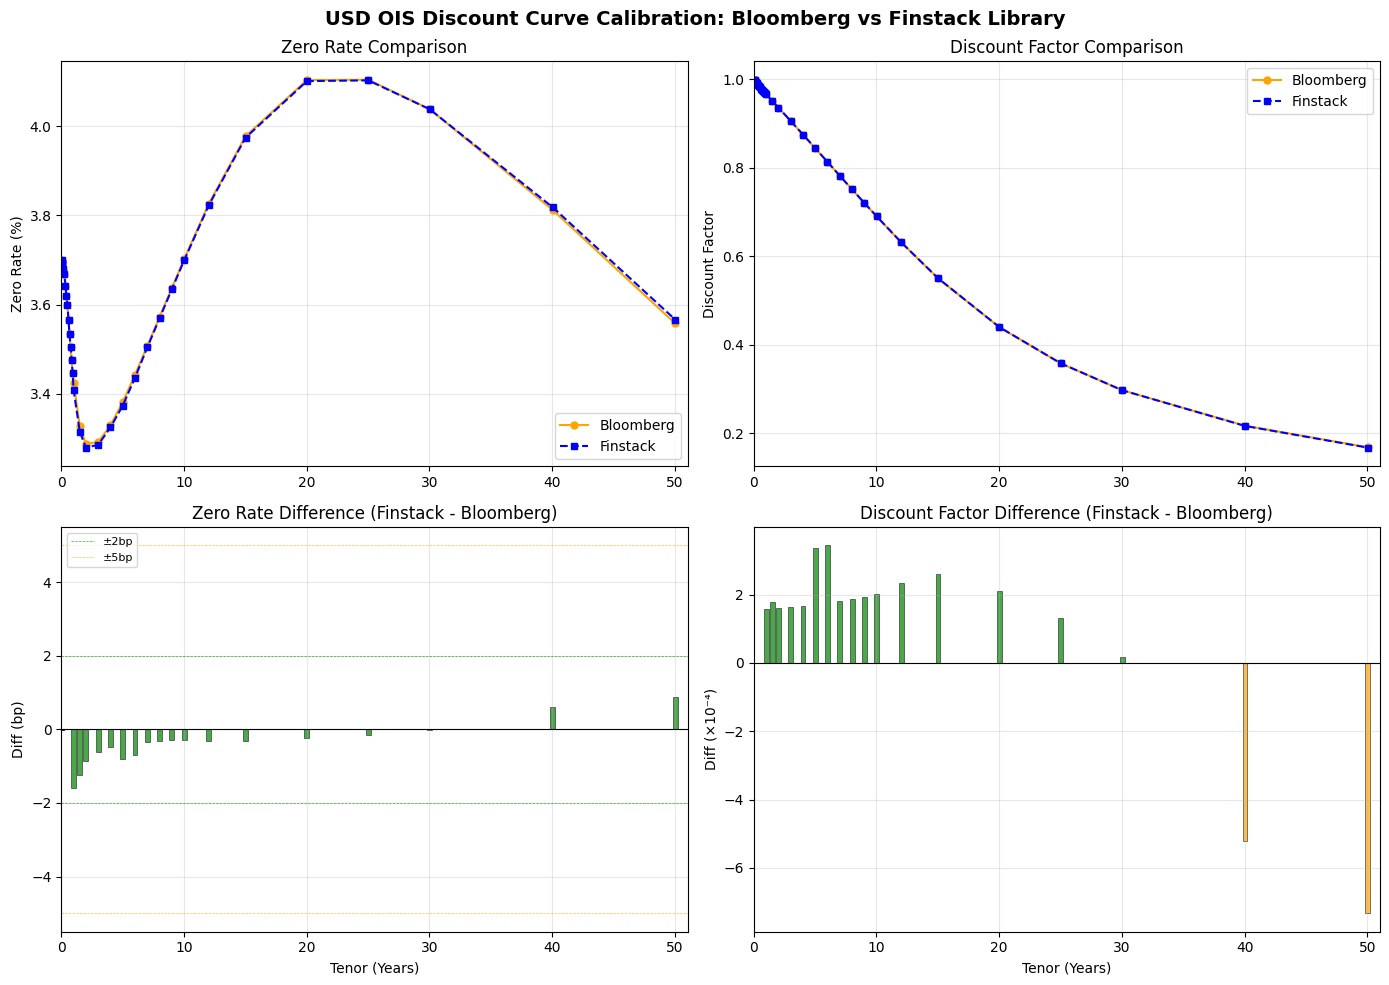


CALIBRATION ACCURACY SUMMARY

Zero Rate Differences (bp):
  Mean:        -0.22 bp
  Std Dev:      0.46 bp
  Max Abs:      1.61 bp at 1.0Y

Discount Factor Differences (×10⁻⁴):
  Mean:         0.59
  Max Abs:      7.33 at 50.0Y


In [ ]:
# Plot zero rate and discount factor comparison: Bloomberg vs Finstack
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ax1, ax2, ax3, ax4 = axes.flatten()

# Collect data for plotting
tenors = []
bbg_zeros = []
calc_zeros = []
bbg_dfs = []
calc_dfs = []

for mat_date, bbg_zero, bbg_df in bloomberg_data:
    days = (mat_date - base_date).days
    t = days / 365.0
    tenors.append(t)
    bbg_zeros.append(bbg_zero)
    calc_zeros.append(discount_curve.zero_on_date(mat_date) * 100)
    bbg_dfs.append(bbg_df)
    calc_dfs.append(discount_curve.df_on_date(mat_date))

# Top left: Zero rates comparison
ax1.plot(tenors, bbg_zeros, 'o-', color='orange', label='Bloomberg', markersize=5, linewidth=1.5)
ax1.plot(tenors, calc_zeros, 's--', color='blue', label='Finstack', markersize=4, linewidth=1.5)
ax1.set_ylabel('Zero Rate (%)')
ax1.set_title('Zero Rate Comparison')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max(tenors) + 1)
#ax1.set_ylim(0.0, 4.5)

# Top right: Discount factor comparison
ax2.plot(tenors, bbg_dfs, 'o-', color='orange', label='Bloomberg', markersize=5, linewidth=1.5)
ax2.plot(tenors, calc_dfs, 's--', color='blue', label='Finstack', markersize=4, linewidth=1.5)
ax2.set_ylabel('Discount Factor')
ax2.set_title('Discount Factor Comparison')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max(tenors) + 1)

# Bottom left: Zero rate difference in bp
zero_diffs_bp = [(c - b) * 100 for c, b in zip(calc_zeros, bbg_zeros)]
colors = ['green' if abs(d) < 2 else 'orange' if abs(d) < 5 else 'red' for d in zero_diffs_bp]
ax3.bar(tenors, zero_diffs_bp, width=0.4, color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax3.axhline(y=2, color='green', linestyle='--', linewidth=0.5, alpha=0.7, label='±2bp')
ax3.axhline(y=-2, color='green', linestyle='--', linewidth=0.5, alpha=0.7)
ax3.axhline(y=5, color='orange', linestyle='--', linewidth=0.5, alpha=0.7, label='±5bp')
ax3.axhline(y=-5, color='orange', linestyle='--', linewidth=0.5, alpha=0.7)
ax3.set_xlabel('Tenor (Years)')
ax3.set_ylabel('Diff (bp)')
ax3.set_title('Zero Rate Difference (Finstack - Bloomberg)')
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, max(tenors) + 1)

# Bottom right: Discount factor difference (in bp equivalent)
df_diffs = [(c - b) * 10000 for c, b in zip(calc_dfs, bbg_dfs)]  # Scale to bp-like units
colors_df = ['green' if abs(d) < 5 else 'orange' if abs(d) < 20 else 'red' for d in df_diffs]
ax4.bar(tenors, df_diffs, width=0.4, color=colors_df, alpha=0.7, edgecolor='black', linewidth=0.5)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_xlabel('Tenor (Years)')
ax4.set_ylabel('Diff (×10⁻⁴)')
ax4.set_title('Discount Factor Difference (Finstack - Bloomberg)')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, max(tenors) + 1)

plt.suptitle('USD OIS Discount Curve Calibration: Bloomberg vs Finstack Library', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("CALIBRATION ACCURACY SUMMARY")
print("="*70)
print(f"\nZero Rate Differences (bp):")
print(f"  Mean:     {sum(zero_diffs_bp)/len(zero_diffs_bp):>8.2f} bp")
print(f"  Std Dev:  {(sum((d - sum(zero_diffs_bp)/len(zero_diffs_bp))**2 for d in zero_diffs_bp)/len(zero_diffs_bp))**0.5:>8.2f} bp")
print(f"  Max Abs:  {max(abs(d) for d in zero_diffs_bp):>8.2f} bp at {tenors[zero_diffs_bp.index(max(zero_diffs_bp, key=abs))]:.1f}Y")
print(f"\nDiscount Factor Differences (×10⁻⁴):")
print(f"  Mean:     {sum(df_diffs)/len(df_diffs):>8.2f}")
print(f"  Max Abs:  {max(abs(d) for d in df_diffs):>8.2f} at {tenors[df_diffs.index(max(df_diffs, key=abs))]:.1f}Y")